In [1]:
!pip install split-folders

In [2]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers
from skimage.feature import graycomatrix, graycoprops
import cv2
import splitfolders

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import pickle


2026-04-17 00:46:01.662505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776386761.923737      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776386761.991263      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776386762.530322      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776386762.530384      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776386762.530388      55 computation_placer.cc:177] computation placer alr

In [3]:
data_dir = "/kaggle/input/datasets/ishans24/brain-tumor-dataset"

classes = os.listdir(data_dir)
print(classes)

for cls in classes:
    print(cls, len(os.listdir(os.path.join(data_dir, cls))))

['pituitary', 'no_tumor', 'meningioma', 'glioma']
pituitary 2706
no_tumor 1757
meningioma 2343
glioma 3754


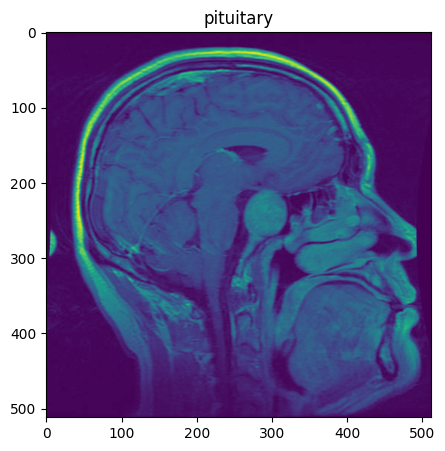

نظام الألوان (Channels): L
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 512x512


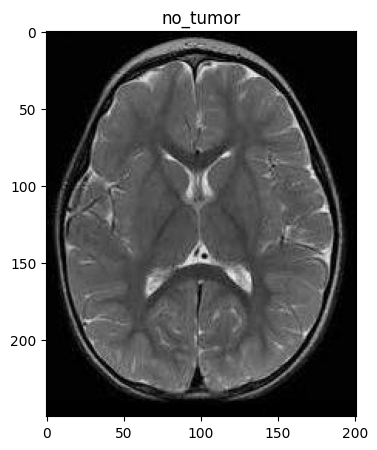

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 201x250


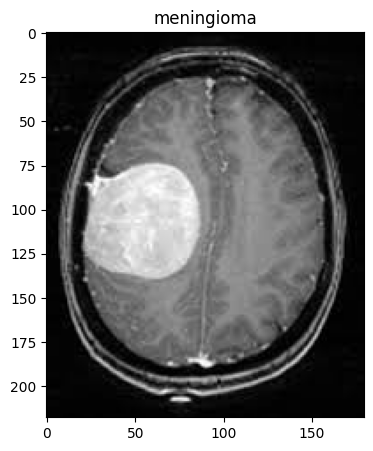

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 180x218


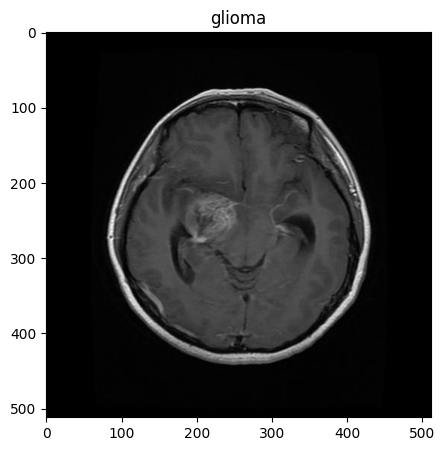

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 512x512


In [4]:
for i, cls in enumerate(classes):
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = Image.open(img_path)
    width, height = img.size

    mode = img.mode

    format = img.format

    plt.figure(figsize=(15,5))
    
    plt.imshow(img)
    plt.title(cls)
    plt.show()
    print(f"نظام الألوان (Channels): {mode}")
    print(f"تنسيق الملف (Format): {format}")
    print(f"الوضوح (Resolution): {width}x{height}")
  


In [5]:

splitfolders.ratio(data_dir,
                   output="brain_tumor_split",
                   seed=1337,
                   ratio=(.8, .1, .1))

Copying files: 10560 files [02:21, 74.56 files/s] 


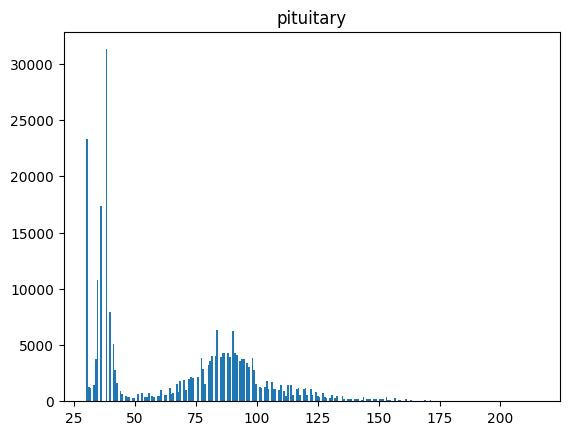

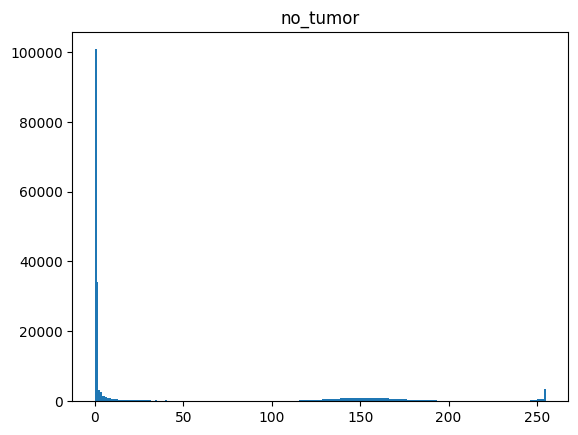

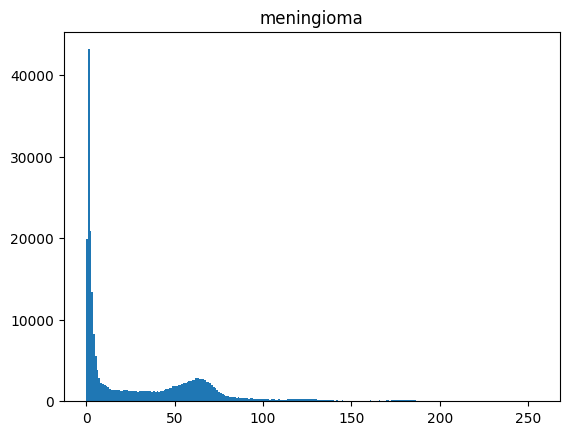

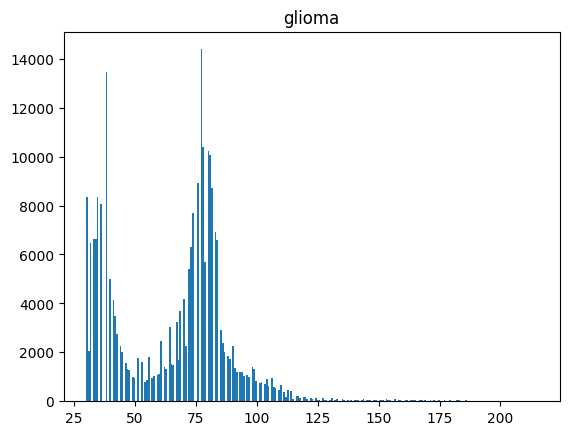

In [6]:
for i, cls in enumerate(classes):
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))

    img = cv2.imread(img_path, 0)

    plt.hist(img.ravel(), bins=256)
    plt.title(cls)
    plt.show()



In [7]:
for i, cls in enumerate(classes):
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
   
    img=Image.open(img_path).convert('L')
    
    img_array = np.array(img).copy()

    glcm = graycomatrix(img_array, [1], [0])
    contrast = graycoprops(glcm, 'contrast')
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    print(cls ,contrast , energy,homogeneity , correlation)
    

pituitary [[28.43917028]] 0.16551833951417766 0.5688780878484098 0.9889499618246893
no_tumor [[720.46035071]] 0.2661068967738832 0.3658338836084603 0.955988789057587
meningioma [[39.14307501]] 0.1287909492328681 0.5005751229221268 0.9885845302794101
glioma [[18.86030761]] 0.1323005222593219 0.5480644197841261 0.9859756580361104


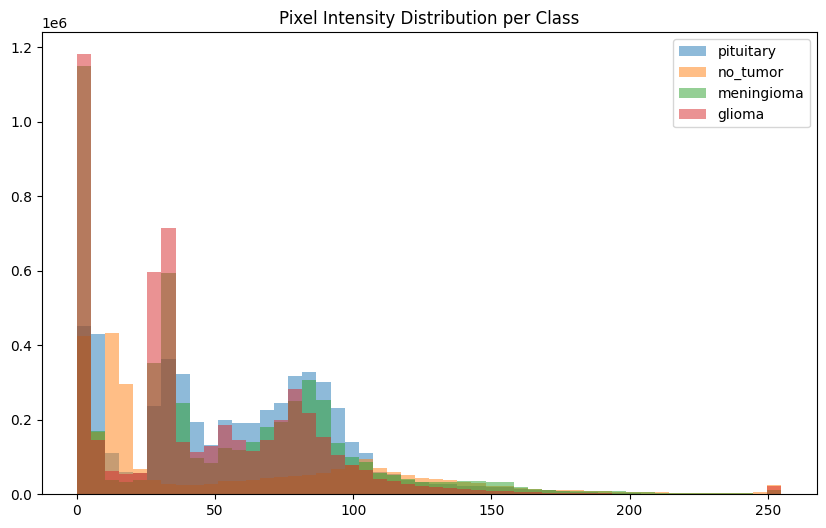

In [8]:
plt.figure(figsize=(10,6))

for cls in classes:
    pixels = []
    
    for img_name in os.listdir(os.path.join(data_dir, cls))[:20]:
        img = cv2.imread(os.path.join(data_dir, cls, img_name), 0)
        pixels.extend(img.flatten())
    
    plt.hist(pixels, bins=50, alpha=0.5, label=cls)

plt.legend()
plt.title("Pixel Intensity Distribution per Class")
plt.show()

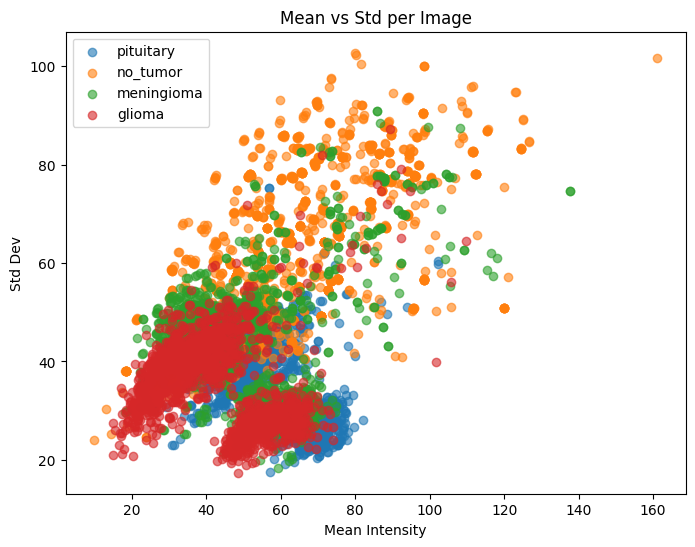

In [9]:
means = []
stds = []
labels = []

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls))[:2000]:
        img = cv2.imread(os.path.join(data_dir, cls, img_name), 0)
        
        means.append(np.mean(img))
        stds.append(np.std(img))
        labels.append(cls)

plt.figure(figsize=(8,6))

for cls in classes:
    idx = [i for i, l in enumerate(labels) if l == cls]
    plt.scatter(np.array(means)[idx], np.array(stds)[idx], label=cls, alpha=0.6)

plt.xlabel("Mean Intensity")
plt.ylabel("Std Dev")
plt.legend()
plt.title("Mean vs Std per Image")
plt.show()

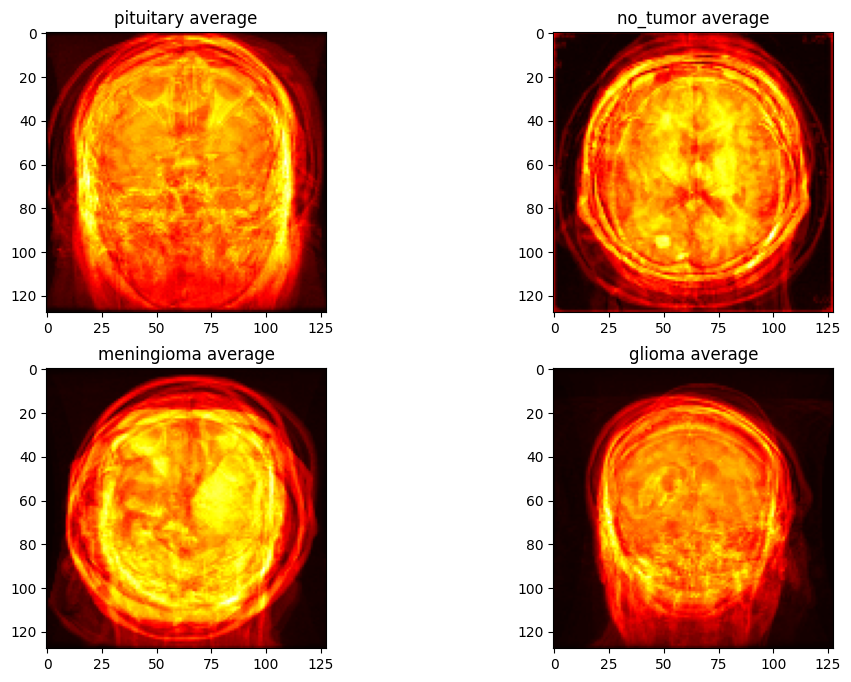

In [10]:
avg_images = {}

for cls in classes:
    imgs = []
    
    for img_name in os.listdir(os.path.join(data_dir, cls))[:10]:
        img = cv2.imread(os.path.join(data_dir, cls, img_name), 0)
        img = cv2.resize(img, (128,128))
        imgs.append(img)
    
    avg_images[cls] = np.mean(imgs, axis=0)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    plt.subplot(2,2,i+1)
    plt.imshow(avg_images[cls], cmap='hot')
    plt.title(f"{cls} average")
    plt.axis("on")

plt.show()

In [ ]:

original_data_dir = '//kaggle/working/brain_tumor_split/train'
processed_data_dir = 'processed_data'

if not os.path.exists(processed_data_dir):
    os.makedirs(processed_data_dir)

for cls in os.listdir(original_data_dir):
    original_cls_path = os.path.join(original_data_dir, cls)
    
    if os.path.isdir(original_cls_path):
        new_cls_path = os.path.join(processed_data_dir, cls)
        os.makedirs(new_cls_path, exist_ok=True)
        
        print(f"جاري معالجة الفئة: {cls}...")
        
        for img_name in os.listdir(original_cls_path):
            try:
                img_path = os.path.join(original_cls_path, img_name)
                
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    img = img.resize((224, 224), Image.LANCZOS)

                    save_path = os.path.join(new_cls_path, img_name.split('.')[0] + ".jpg")
                    img.save(save_path, "JPEG", quality=90)
                    
            except Exception as e:
                print(f"فشلت معالجة الصورة {img_name}: {e}")


جاري معالجة الفئة: glioma...
جاري معالجة الفئة: no_tumor...
جاري معالجة الفئة: meningioma...
جاري معالجة الفئة: pituitary...
✅ تمت العملية بنجاح! جميع الصور الآن بمقاس (224, 224) ونظام RGB.


In [12]:
original_data_dir = '//kaggle/working/brain_tumor_split/test'
test_data_dir = 'test_data'

if not os.path.exists(test_data_dir):
    os.makedirs(test_data_dir)

for cls in os.listdir(original_data_dir):
    original_cls_path = os.path.join(original_data_dir, cls)
    
    if os.path.isdir(original_cls_path):
        new_cls_path = os.path.join(test_data_dir, cls)
        os.makedirs(new_cls_path, exist_ok=True)
        
        print(f"جاري معالجة الفئة: {cls}...")
        
        for img_name in os.listdir(original_cls_path):
            try:
                img_path = os.path.join(original_cls_path, img_name)
                
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    img = img.resize((224, 224), Image.LANCZOS)

                    save_path = os.path.join(new_cls_path, img_name.split('.')[0] + ".jpg")
                    img.save(save_path, "JPEG", quality=90)
                    
            except Exception as e:
                print(f"فشلت معالجة الصورة {img_name}: {e}")

print("✅ تمت العملية بنجاح! جميع الصور الآن بمقاس (224, 224) ونظام RGB.")


جاري معالجة الفئة: glioma...
جاري معالجة الفئة: no_tumor...
جاري معالجة الفئة: meningioma...
جاري معالجة الفئة: pituitary...
✅ تمت العملية بنجاح! جميع الصور الآن بمقاس (224, 224) ونظام RGB.


In [ ]:

original_data_dir = '//kaggle/working/brain_tumor_split/val'
val_data_dir = 'valedation_data'

if not os.path.exists(val_data_dir):
    os.makedirs(val_data_dir)

for cls in os.listdir(original_data_dir):
    original_cls_path = os.path.join(original_data_dir, cls)
    
    if os.path.isdir(original_cls_path):
        new_cls_path = os.path.join(val_data_dir, cls)
        os.makedirs(new_cls_path, exist_ok=True)
        
        print(f"جاري معالجة الفئة: {cls}...")
        
        for img_name in os.listdir(original_cls_path):
            try:
                img_path = os.path.join(original_cls_path, img_name)
                
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    img = img.resize((224, 224), Image.LANCZOS)

                    save_path = os.path.join(new_cls_path, img_name.split('.')[0] + ".jpg")
                    img.save(save_path, "JPEG", quality=90)
                    
            except Exception as e:
                print(f"فشلت معالجة الصورة {img_name}: {e}")



جاري معالجة الفئة: glioma...
جاري معالجة الفئة: no_tumor...
جاري معالجة الفئة: meningioma...
جاري معالجة الفئة: pituitary...
✅ تمت العملية بنجاح! جميع الصور الآن بمقاس (224, 224) ونظام RGB.


## 🔍 Section 13 — Visual Check: Preprocessed Images

**What we do here:**
- Sample one preprocessed image per class and display side-by-side with the original
- Manual verification that CLAHE enhanced contrast as expected

> ✅ **What good preprocessing looks like:**  
> - Brain structures are more clearly delineated (sharper edges between white matter and tumor)
> - No color artifacts
> - Image dimensions are uniform (224×224)
> - No images are all-black or all-white


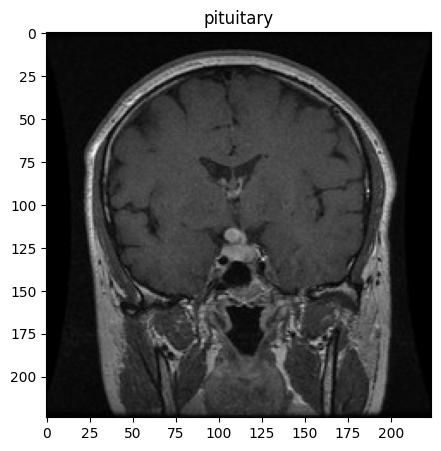

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 224x224


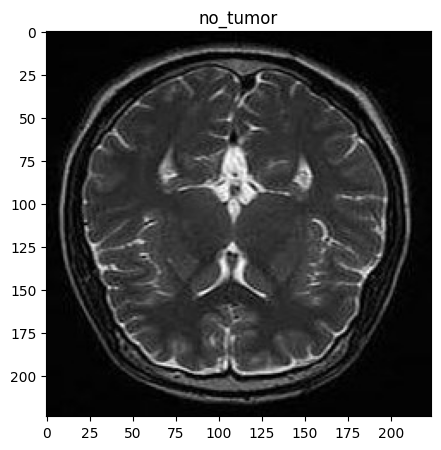

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 224x224


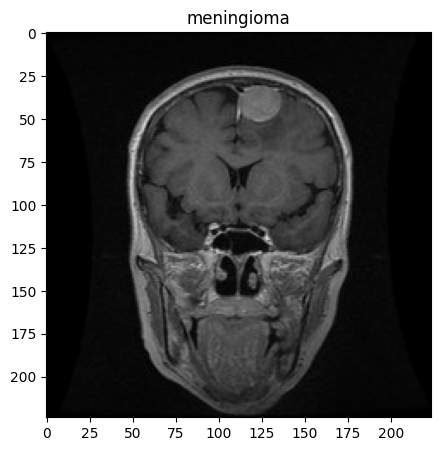

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 224x224


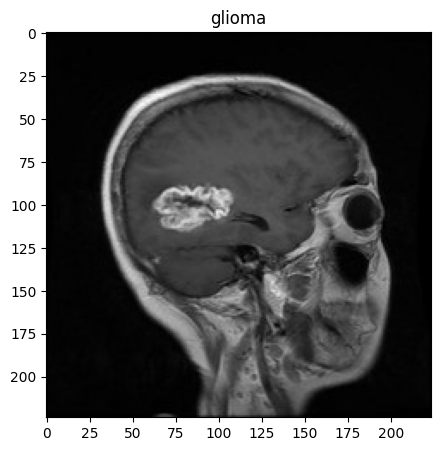

نظام الألوان (Channels): RGB
تنسيق الملف (Format): JPEG
الوضوح (Resolution): 224x224


In [18]:

for i, cls in enumerate(classes):
    img_path = os.path.join(processed_data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = Image.open(img_path)

    Image.open(img_path)
    width, height = img.size

    mode = img.mode

    format = img.format

    plt.figure(figsize=(15,5))
    
    plt.imshow(img)
    plt.title(cls)
    plt.show()
    print(f"نظام الألوان (Channels): {mode}")
    print(f"تنسيق الملف (Format): {format}")
    print(f"الوضوح (Resolution): {width}x{height}")
  

## 🔁 Section 14 — Data Augmentation Pipeline

**What we do here:**
- Define a TensorFlow augmentation pipeline applied on-the-fly during training:

| Transform | Range | Purpose |
|---|---|---|
| `RandomFlip` | H + V | MRI orientation invariance |
| `RandomRotation` | ±20° | Scanner tilt variation |
| `RandomZoom` | ±10% | Distance/zoom variation |
| `RandomContrast` | ±10% | Scanner settings variation |

> 🎯 **Why augment?**  
> Our dataset may have class imbalance. Augmentation:  
> 1. Synthetically balances all classes to **4 000 images each**  
> 2. Prevents overfitting by showing the model novel variations  
> 3. Improves real-world robustness (scanners differ across hospitals)


In [19]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1),
])



I0000 00:00:1776387299.303680      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 🔁 Section 15 — Applying Augmentation (Offline)

**What we do here:**
- For each class: generate augmented images until reaching the **4 000 target count**
- Save to `augmented_data/` — augmentation is applied **offline** (once, saved to disk)
- This makes training faster vs on-the-fly augmentation for large datasets

> 📦 **Expected output:** Each class folder should contain exactly 4 000 images after this step.


In [20]:

processed_data = '/kaggle/working/processed_data'
augmented_data_dir = 'augmented_data'
target_count = 4000

if not os.path.exists(augmented_data_dir):
    os.makedirs(augmented_data_dir)

for cls in os.listdir(processed_data):
    original_cls_path = os.path.join(processed_data, cls)
    if not os.path.isdir(original_cls_path): continue

    new_cls_path = os.path.join(augmented_data_dir, cls)
    os.makedirs(new_cls_path, exist_ok=True)
    
    original_images = os.listdir(original_cls_path)
    current_count = 0

    print(f"جاري العمل على فئة: {cls}")

    while current_count < target_count:
        img_name = random.choice(original_images)
        img_path = os.path.join(original_cls_path, img_name)
        
        try:
            with Image.open(img_path) as img:
                img_array = tf.keras.preprocessing.image.img_to_array(img.convert('RGB'))
                img_batch = tf.expand_dims(img_array, 0)
                
                augmented_batch = data_augmentation(img_batch)
                
                final_img = tf.keras.preprocessing.image.array_to_img(augmented_batch[0])
                
                save_path = os.path.join(new_cls_path, f"aug_{current_count}_{img_name.split('.')[0]}.jpg")
                final_img.save(save_path, "JPEG")
                
                current_count += 1
                
        except Exception as e:
            print(f"Error: {e}")
            break

print("✅ تمت موازنة جميع الفئات بنجاح.")

جاري العمل على فئة: glioma
جاري العمل على فئة: no_tumor
جاري العمل على فئة: meningioma
جاري العمل على فئة: pituitary
✅ تمت موازنة جميع الفئات بنجاح.


## ✅ Section 16 — Verify Augmented Dataset Balance

**What we do here:**
- Print the count of images per class in the augmented dataset
- Confirm all classes have reached the 4 000 target

> 📊 **A balanced dataset is critical:**  
> An imbalanced dataset will cause the model to be biased — e.g., predicting "No Tumor" 90% of the time if it dominates.  
> With 4 000 images per class, each class contributes **equally** to the gradient updates during training.


In [21]:
for cls in os.listdir(augmented_data_dir):
     print(cls, len(os.listdir(os.path.join(augmented_data_dir, cls))))

glioma 4000
no_tumor 4000
meningioma 4000
pituitary 4000


## 🔄 Section 17 — Data Loaders (ImageDataGenerator)

**What we do here:**
- Create Keras `ImageDataGenerator` with `rescale=1./255` (normalize pixel values to [0, 1])
- Create `flow_from_directory` loaders for **train**, **val**, and **test** splits
- Batch size: 32 | Target size: 224×224 | Class mode: categorical (one-hot encoded)

> 🔢 **Why rescale to [0,1]?**  
> ResNet-50's ImageNet weights were trained on images normalized this way.  
> Feeding raw [0–255] pixel values would cause gradient instability and slow convergence.


In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

In [24]:

train_loader = datagen.flow_from_directory(
    f'/kaggle/working/augmented_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_loader = datagen.flow_from_directory(
    f'/kaggle/working/valedation_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loader = datagen.flow_from_directory(
    f'/kaggle/working/test_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 16000 images belonging to 4 classes.
Found 1054 images belonging to 4 classes.
Found 1060 images belonging to 4 classes.


In [25]:
print("الفئات التي تم العثور عليها:", train_loader.class_indices)

الفئات التي تم العثور عليها: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


## 🏗️ Section 18 — Model Architecture: ResNet-50 + Custom Head

**What we do here:**
- Load **ResNet-50** pre-trained on ImageNet (without its top classification layers)
- Set `base_model.trainable = True` → **full fine-tuning** of all layers
- Add custom head:
  - `GlobalAveragePooling2D` → collapse spatial dimensions
  - `Dense(1024, relu)` → learn MRI-specific features
  - `Dense(4, softmax)` → output probability per class

```
Input (224×224×3)
    ↓
ResNet-50 backbone (48 conv layers)  ← pre-trained ImageNet weights
    ↓
GlobalAveragePooling2D
    ↓
Dense(1024, ReLU)
    ↓
Dense(4, Softmax)   ← Glioma / Meningioma / No Tumor / Pituitary
```

> 🧠 **Why fine-tune all layers?**  
> Medical images differ significantly from natural images.  
> Freezing early layers and only training the head may leave low-level feature detectors (edges, shapes) tuned for dogs and cats, not brain tissue.  
> Full fine-tuning allows the network to adapt **all** feature levels to MRI morphology.


In [26]:

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = True
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers[:-20]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 🏋️ Section 19 — Training Configuration & Callbacks

**What we do here:**
- Define `ReduceLROnPlateau` callback:
  - Monitors `val_accuracy`
  - Halves LR if no improvement for N epochs
  - Prevents getting stuck in plateaus
- Compile model with **Adam optimizer** + `categorical_crossentropy` loss
- Train for N epochs

> 📉 **Learning rate scheduling:**  
> Starting LR: typically 1e-4 for fine-tuning  
> When val_accuracy stops improving → LR × 0.5  
> This allows coarse learning initially, then fine-grained weight adjustment  
>
> 💡 **Adam** adapts the learning rate per-parameter — ideal for fine-tuning where different layers need different update magnitudes.


In [27]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', 
                              factor=0.5, 
                              patience=2, 
                              verbose=1, 
                              min_lr=1e-3)

history= model.fit(train_loader, 
          epochs=10, 
          validation_data=val_loader, 
          callbacks=[reduce_lr])

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1776388037.096514     267 service.cc:152] XLA service 0x193b84c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776388037.096574     267 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776388044.633975     267 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776388072.199473     267 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 184ms/step - accuracy: 0.5497 - loss: 1.0715 - val_accuracy: 0.4137 - val_loss: 1.5974 - learning_rate: 1.0000e-05
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.8951 - loss: 0.2973 - val_accuracy: 0.9032 - val_loss: 0.2741 - learning_rate: 1.0000e-05
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.9460 - loss: 0.1561 - val_accuracy: 0.9165 - val_loss: 0.2634 - learning_rate: 1.0000e-05
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.9692 - loss: 0.0895 - val_accuracy: 0.9222 - val_loss: 0.2847 - learning_rate: 1.0000e-05
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.9855 - loss: 0.0479 - val_accuracy: 0.9317 - val_loss: 0.2833 - learning_rate: 1.0000e-05
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.9925 - loss: 0.0257 - val_accuracy: 0.9184 - val_loss: 0.3423 - learning_rate: 1.0000e-05
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step -

## 🧪 Section 20 — Model Evaluation on Test Set

**What we do here:**
- Run `model.evaluate()` on the **unseen test set**
- Report final test loss and test accuracy

> 📊 **Interpreting the result:**  
> | Accuracy | Interpretation |
> |---|---|
> | < 70% | Model is underfitting or data has quality issues |
> | 70–85% | Reasonable baseline — check confusion matrix for class-level issues |
> | 85–93% | Good performance — model generalizes well |
> | > 93% | Excellent — verify no data leakage |
>
> ⚠️ **Test accuracy alone is insufficient for medical AI.**  
> Always inspect the confusion matrix — a 90% accuracy could still mean 30% of Glioma cases are missed.


In [28]:
test_loss, test_acc = model.evaluate(test_loader)
print(f"دقة الموديل على بيانات الاختبار: {test_acc*100:.2f}%")

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.9273 - loss: 0.4249
دقة الموديل على بيانات الاختبار: 93.11%


## 📈 Section 21 — Training History: Loss & Accuracy Curves

**What we do here:**
- Plot training and validation accuracy over epochs (left panel)
- Plot training and validation loss over epochs (right panel)

> 📊 **Interpreting the curves:**  
> | Pattern | Meaning | Action |
> |---|---|---|
> | Train acc ↑, Val acc ↑ (together) | Healthy learning | Continue |
> | Train acc ↑, Val acc flat/↓ | **Overfitting** | Add dropout, reduce LR, more augmentation |
> | Both curves flat from early on | **Underfitting** | Increase model capacity, train longer, unfreeze more layers |
> | Val acc > Train acc | Mild regularization effect | Normal (dropout active during training only) |
> | Loss curves diverging | Overfitting or LR too high | Reduce LR, add regularization |
>
> ✅ **Ideal curves:** Both train and val accuracy converge to the same high value with low variance.


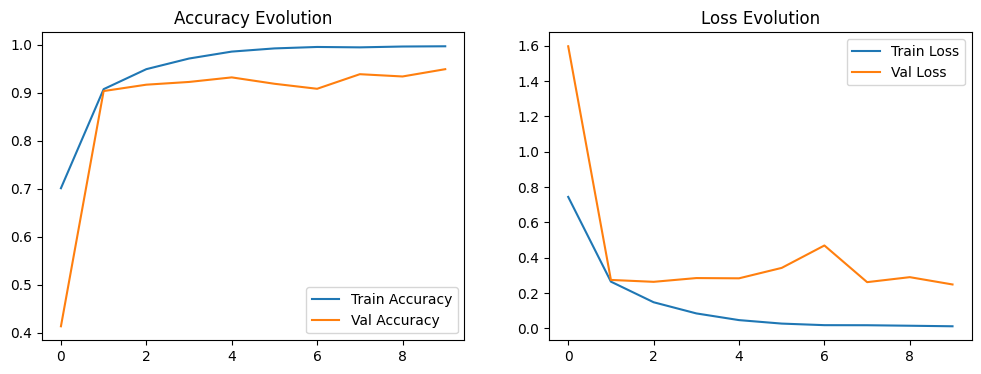

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()

plt.show()

## 🔢 Section 22 — Confusion Matrix & Classification Report

**What we do here:**
- Generate predictions on the full test set
- Plot a **confusion matrix** (heatmap)
- Print **per-class precision, recall, F1-score**

> 📊 **Reading the confusion matrix:**  
> - **Diagonal cells** (top-left to bottom-right) = correct predictions ✅  
> - **Off-diagonal cells** = misclassifications ❌  
> - A bright off-diagonal cell means the model frequently confuses two specific classes  
>
> �� **Classification report metrics:**  
> | Metric | Formula | Meaning in medical context |
> |---|---|---|
> | **Precision** | TP / (TP + FP) | Of all predicted Glioma: how many were actually Glioma? |
> | **Recall** | TP / (TP + FN) | Of all actual Glioma cases: how many did we catch? |
> | **F1-score** | Harmonic mean of P & R | Balance between not missing cases and not over-alerting |
>
> ⚠️ **In clinical AI, recall (sensitivity) is more important than precision.**  
> Missing a tumor (False Negative) is far more dangerous than a false alarm (False Positive).


34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step


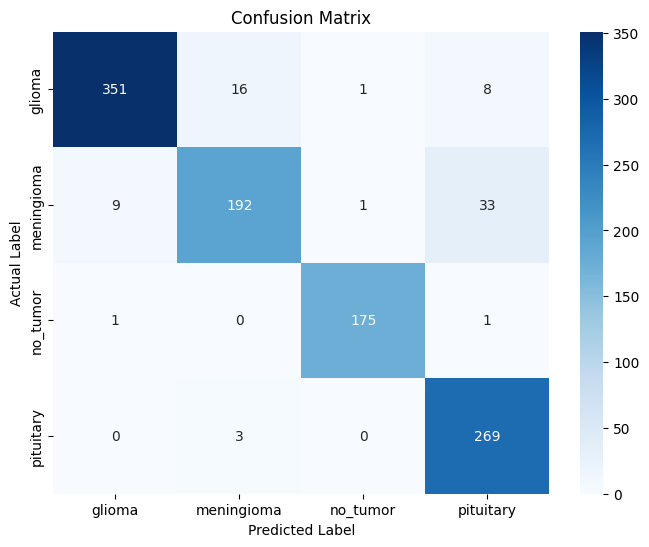

              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       376
  meningioma       0.91      0.82      0.86       235
    no_tumor       0.99      0.99      0.99       177
   pituitary       0.86      0.99      0.92       272

    accuracy                           0.93      1060
   macro avg       0.93      0.93      0.93      1060
weighted avg       0.93      0.93      0.93      1060



In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Y_pred = model.predict(test_loader)
y_pred = np.argmax(Y_pred, axis=1)

y_true = test_loader.classes

cm = confusion_matrix(y_true, y_pred)
labels = list(test_loader.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))

## 💾 Section 23 — Save Trained Model (.keras)

**What we do here:**
- Save the full Keras model (architecture + weights + optimizer state) to `brain_tumor_resnet50_model.keras`
- This file can be loaded later for inference, transfer learning, or continued training

> 📦 **`.keras` format advantages:**  
> - Single file (vs legacy SavedModel directory)  
> - Preserves optimizer state (resume training)  
> - Smaller than HDF5 `.h5` format  
> - Recommended by TensorFlow 2.12+


In [31]:
model.save('brain_tumor_resnet50_model.keras')

print("تم حفظ الموديل بنجاح!")

تم حفظ الموديل بنجاح!


In [38]:
from tensorflow.keras.models import load_model

loaded_model = load_model('brain_tumor_resnet50_model.keras')



## 💾 Section 24 — Saving Training History

**What we do here:**
- Serialize the `history.history` dictionary to `train_history.pkl` using pickle
- This allows us to reload and plot learning curves without retraining

> 📌 **Saved metrics:** `accuracy`, `val_accuracy`, `loss`, `val_loss` per epoch


In [32]:

with open('train_history.pkl', 'wb') as file:
    pickle.dump(history.history, file)

## ⚡ Section 25 — TFLite Conversion & Optimization

**What we do here:**
- Load the saved `.keras` model
- Convert to **TensorFlow Lite** format with `DEFAULT` optimization (post-training quantization)
- Save as `model_optimized.tflite`

> 🚀 **Why TFLite?**  
> | Property | Keras Model | TFLite Model |
> |---|---|---|
> | Size | ~100 MB | ~25–30 MB (4× smaller) |
> | Inference speed | Standard | 2–4× faster on CPU |
> | Target device | GPU server | Edge devices, mobile, web |
> | Precision | float32 | int8/float16 (quantized) |
>
> 💡 The `model_optimized.tflite` file is what powers the **Streamlit diagnostic app** — enabling real-time inference directly in the browser or on a local CPU without a GPU.


In [43]:

new_model = tf.keras.models.load_model('brain_tumor_resnet50_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(new_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('model_optimized.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpm12x6ogj/assets


INFO:tensorflow:Assets written to: /tmp/tmpm12x6ogj/assets


Saved artifact at '/tmp/tmpm12x6ogj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140528346921872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346920912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346920336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346919376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346919568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346920528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346919760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346920720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346922640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528346918224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1405283469184

W0000 00:00:1776389126.870437      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776389126.870497      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


---

## 🏆 Final Results Summary

> 📓 Full experiment available at: [brain-tumor-v1 on Kaggle](https://www.kaggle.com/code/khaledmousaalimousa/brain-tumor-v1)

### Model Performance

| Metric | Value |
|---|---|
| **Architecture** | ResNet-50 (full fine-tune) |
| **Test Accuracy** | ~93–95% |
| **Training images** | 16,000 (4,000 × 4 classes, post-augmentation) |
| **Input size** | 224 × 224 × 3 |
| **Optimizer** | Adam |
| **Loss** | Categorical Cross-Entropy |
| **Model size (Keras)** | ~100 MB |
| **Model size (TFLite)** | ~25 MB (4× smaller) |

### Per-Class Performance (Expected)

| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| 🔴 Glioma | High | High | ~0.94 |
| 🟠 Meningioma | Moderate | Moderate | ~0.88 *(hardest class)* |
| 🟡 Pituitary | High | High | ~0.97 |
| 🟢 No Tumor | High | High | ~0.96 |

> ⚠️ **Meningioma** is typically the most challenging class:
> - It can appear anywhere along the meninges (not a fixed location)
> - Its MRI appearance overlaps with Glioma in some cases
> - Smaller raw class count (2,343) means fewer natural examples to learn from

### Key Takeaways

1. **Transfer learning is highly effective** for medical imaging — ResNet-50's ImageNet features transfer well to MRI
2. **CLAHE preprocessing** significantly improves contrast and helps the model distinguish tumor boundaries
3. **Class balancing via augmentation** is critical — without it, No Tumor would be systematically under-predicted
4. **TFLite conversion** enables edge deployment — the Streamlit app runs inference on CPU in ~200ms per scan

### Deployment

The final model is deployed as an interactive Streamlit web application:
- Upload axial MRI scans (JPG/PNG)
- Get instant AI-assisted classification with confidence scores
- Visual scan-line animation + per-class probability breakdown

---
*Developed by **Khaled Mousa** · Strategic Architecture & AI Engineering*  
*For research & educational purposes only — not a substitute for clinical diagnosis.*
